<a href="https://colab.research.google.com/github/shayanazmi/Rep1/blob/main/Crime_Group_Classification_Using_KNN_Based_on_Case_Statistics_of_Crimes_Against_Women_in_India.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **“Crime Group Classification Using KNN Based on Case Statistics of Crimes Against Women in India”**
### Dataset: Cases_under_crime_against_women.csv

**Objectives:**
- Perform Data Exploration on **numeric data**
- Explore **categorical and nominal data**
- Build a **KNN Classification Model**
- Visualize insights and evaluate model performance

---



---
Dataset link = https://www.kaggle.com/datasets/sudhanvahg/indian-crimes-dataset

---
Made by Shayan Azmi

---


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix



---



## Load the dataset
We now load the dataset and display basic information about its structure.

In [3]:
df = pd.read_csv("/content/42_Cases_under_crime_against_women.csv", on_bad_lines='skip')
df.head()

,Area_Name,Year,Group_Name,Sub_Group_Name,Cases_Acquitted_or_Discharged,Cases_charge_sheets_were_not_laid_but_Final_Report_submitted,Cases_Chargesheeted,Cases_Compounded_or_Withdrawn,Cases_Convicted,Cases_Declared_False_on_Account_of_Mistake_of_Fact_or_of_Law,...,Cases_Pending_Investigation_at_Year_End,Cases_Pending_Investigation_from_previous_year,Cases_Pending_Trial_at_Year_End,Cases_Pending_Trial_from_the_previous_year,Cases_Reported,Cases_Sent_for_Trial,Cases_Trials_Completed,Cases_Withdrawn_by_the_Govt,Cases_withdrawn_by_the_Govt_during_investigation,Total_Cases_for_Trial
0,Andaman & Nicobar Islands,2001,Rape,01. Rape,5,2,3,0,0,0,...,1,3,34,36,3,3,5,0,0,39
1,Andhra Pradesh,2001,Rape,01. Rape,731,22,769,35,197,74,...,393,390,1974,2170,871,769,928,2,0,2937
2,Arunachal Pradesh,2001,Rape,01. Rape,1,2,25,0,2,0,...,18,12,282,260,33,25,3,0,0,285
3,Assam,2001,Rape,01. Rape,334,95,495,10,101,45,...,1045,863,1964,1914,817,495,435,0,0,2409
4,Bihar,2001,Rape,01. Rape,406,141,685,0,155,105,...,488,531,3185,3061,888,685,561,0,0,3746




---



## Dataset Overview
Check:
- Shape (rows, columns)
- Missing values
- Column types


In [4]:
df.shape, df.isnull().sum(), df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2765 entries, 0 to 2764
Data columns (total 22 columns):
 #   Column                                                        Non-Null Count  Dtype 
---  ------                                                        --------------  ----- 
 0   Area_Name                                                     2765 non-null   object
 1   Year                                                          2765 non-null   int64 
 2   Group_Name                                                    2765 non-null   object
 3   Sub_Group_Name                                                2765 non-null   object
 4   Cases_Acquitted_or_Discharged                                 2765 non-null   int64 
 5   Cases_charge_sheets_were_not_laid_but_Final_Report_submitted  2765 non-null   int64 
 6   Cases_Chargesheeted                                           2765 non-null   int64 
 7   Cases_Compounded_or_Withdrawn                                 2765 non-null   

((2765, 22),
 Area_Name                                                       0
 Year                                                            0
 Group_Name                                                      0
 Sub_Group_Name                                                  0
 Cases_Acquitted_or_Discharged                                   0
 Cases_charge_sheets_were_not_laid_but_Final_Report_submitted    0
 Cases_Chargesheeted                                             0
 Cases_Compounded_or_Withdrawn                                   0
 Cases_Convicted                                                 0
 Cases_Declared_False_on_Account_of_Mistake_of_Fact_or_of_Law    0
 Cases_Investigated_Chargesheets+FR_Submitted                    0
 Cases_not_Investigated_or_in_which_investigation_was_refused    0
 Cases_Pending_Investigation_at_Year_End                         0
 Cases_Pending_Investigation_from_previous_year                  0
 Cases_Pending_Trial_at_Year_End                 

In [29]:
df.describe()

,Year,Cases_Acquitted_or_Discharged,Cases_charge_sheets_were_not_laid_but_Final_Report_submitted,Cases_Chargesheeted,Cases_Compounded_or_Withdrawn,Cases_Convicted,Cases_Declared_False_on_Account_of_Mistake_of_Fact_or_of_Law,Cases_Investigated_Chargesheets+FR_Submitted,Cases_not_Investigated_or_in_which_investigation_was_refused,Cases_Pending_Investigation_at_Year_End,Cases_Pending_Investigation_from_previous_year,Cases_Pending_Trial_at_Year_End,Cases_Pending_Trial_from_the_previous_year,Cases_Reported,Cases_Sent_for_Trial,Cases_Trials_Completed,Cases_Withdrawn_by_the_Govt,Cases_withdrawn_by_the_Govt_during_investigation,Total_Cases_for_Trial
count,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000
mean,2005.468354,432.139241,68.478843,912.951537,91.889331,186.448101,104.223146,981.430380,1.893309,379.494033,346.141772,3460.588427,3258.840145,1121.396022,912.951537,618.587342,0.726582,0.496926,4171.065099
std,2.877031,1053.222306,226.466541,2318.987649,379.379566,639.689836,423.311526,2454.156715,8.904249,1133.215547,1022.918978,9766.712108,9161.620176,2770.338758,2318.987649,1555.660996,10.865100,5.155302,11244.076721
min,2001.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2003.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,7.000000,6.000000,3.000000,2.000000,1.000000,0.000000,0.000000,9.000000
50%,2005.000000,26.000000,5.000000,74.000000,0.000000,13.000000,1.000000,89.000000,0.000000,31.000000,29.000000,254.000000,236.000000,102.000000,74.000000,52.000000,0.000000,0.000000,318.000000
75%,2008.000000,370.000000,37.000000,685.000000,13.000000,97.000000,40.000000,761.000000,0.000000,230.000000,210.000000,2456.000000,2229.000000,870.000000,685.000000,467.000000,0.000000,0.000000,3024.000000
max,2010.000000,11606.000000,3746.000000,23851.000000,5167.000000,10307.000000,7358.000000,25353.000000,119.000000,17892.000000,16529.000000,114591.000000,110593.000000,27244.000000,23851.000000,17283.000000,306.000000,153.000000,125253.000000


The dataset has 2765 rows and 22 columns, containing 19 numeric case-based attributes and 3 categorical columns (Area, Group, Sub-group).
No missing values exist, indicating high data cleanliness.
The numeric statistics show a wide range between minimum and maximum values due to differences in state population sizes and crime severity.
Some columns (like Cases_Reported and Chargesheeted) have high variance, suggesting strong differentiation between crime groups.



---



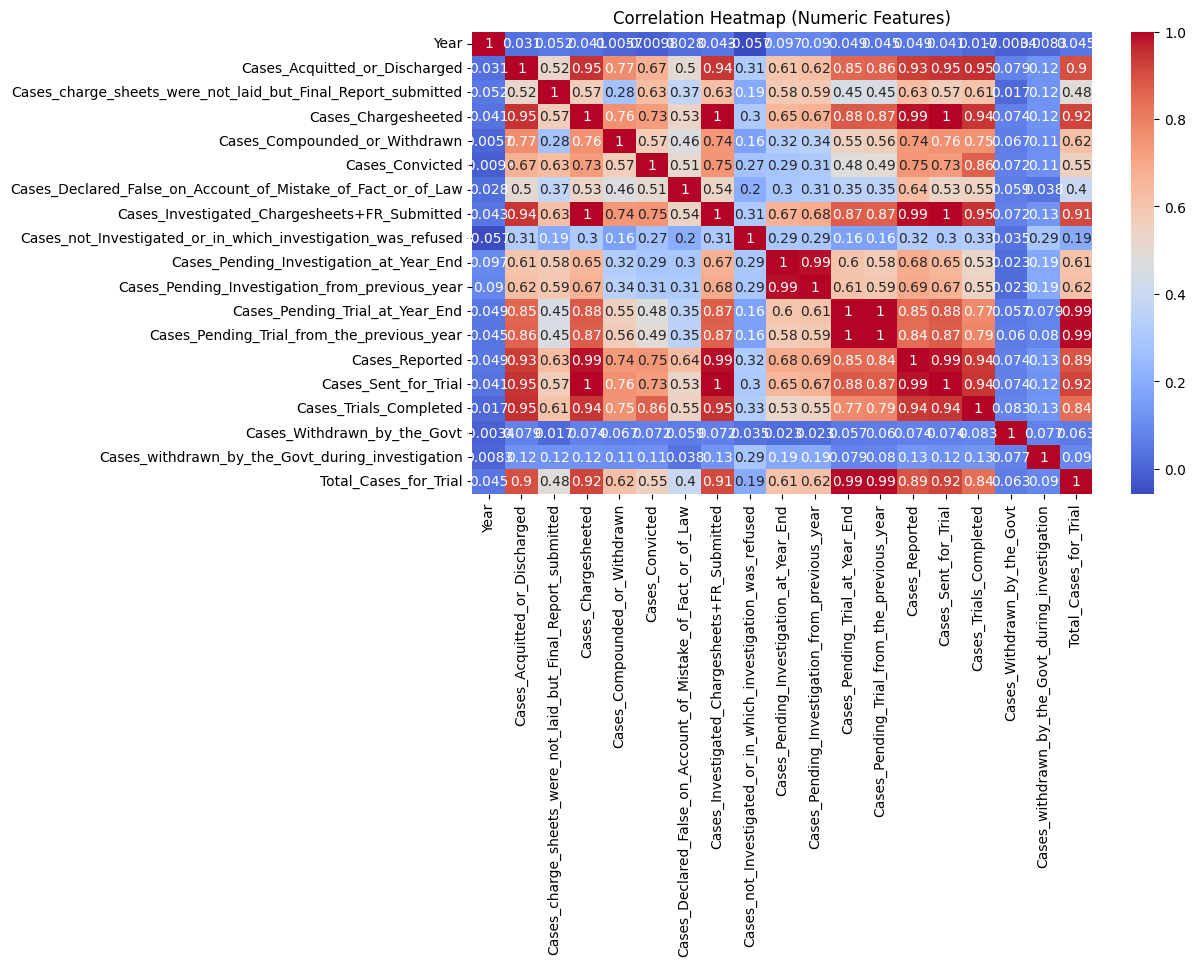

In [5]:
#corelation heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

The heatmap reveals clusters of strongly correlated crime indicators:

Cases_Reported, Cases_Chargesheeted, Cases_Sent_for_Trial, and Cases_Pending_Trial show very strong positive correlation.
This indicates states with high crime reporting also have a heavy burden on the judicial system.

Columns like Cases_Declared_False and Cases_Withdrawn have weak correlations, meaning they behave independently of the main crime load.
These correlations show that crime group types have distinct numeric profiles; which helps KNN classification.



---



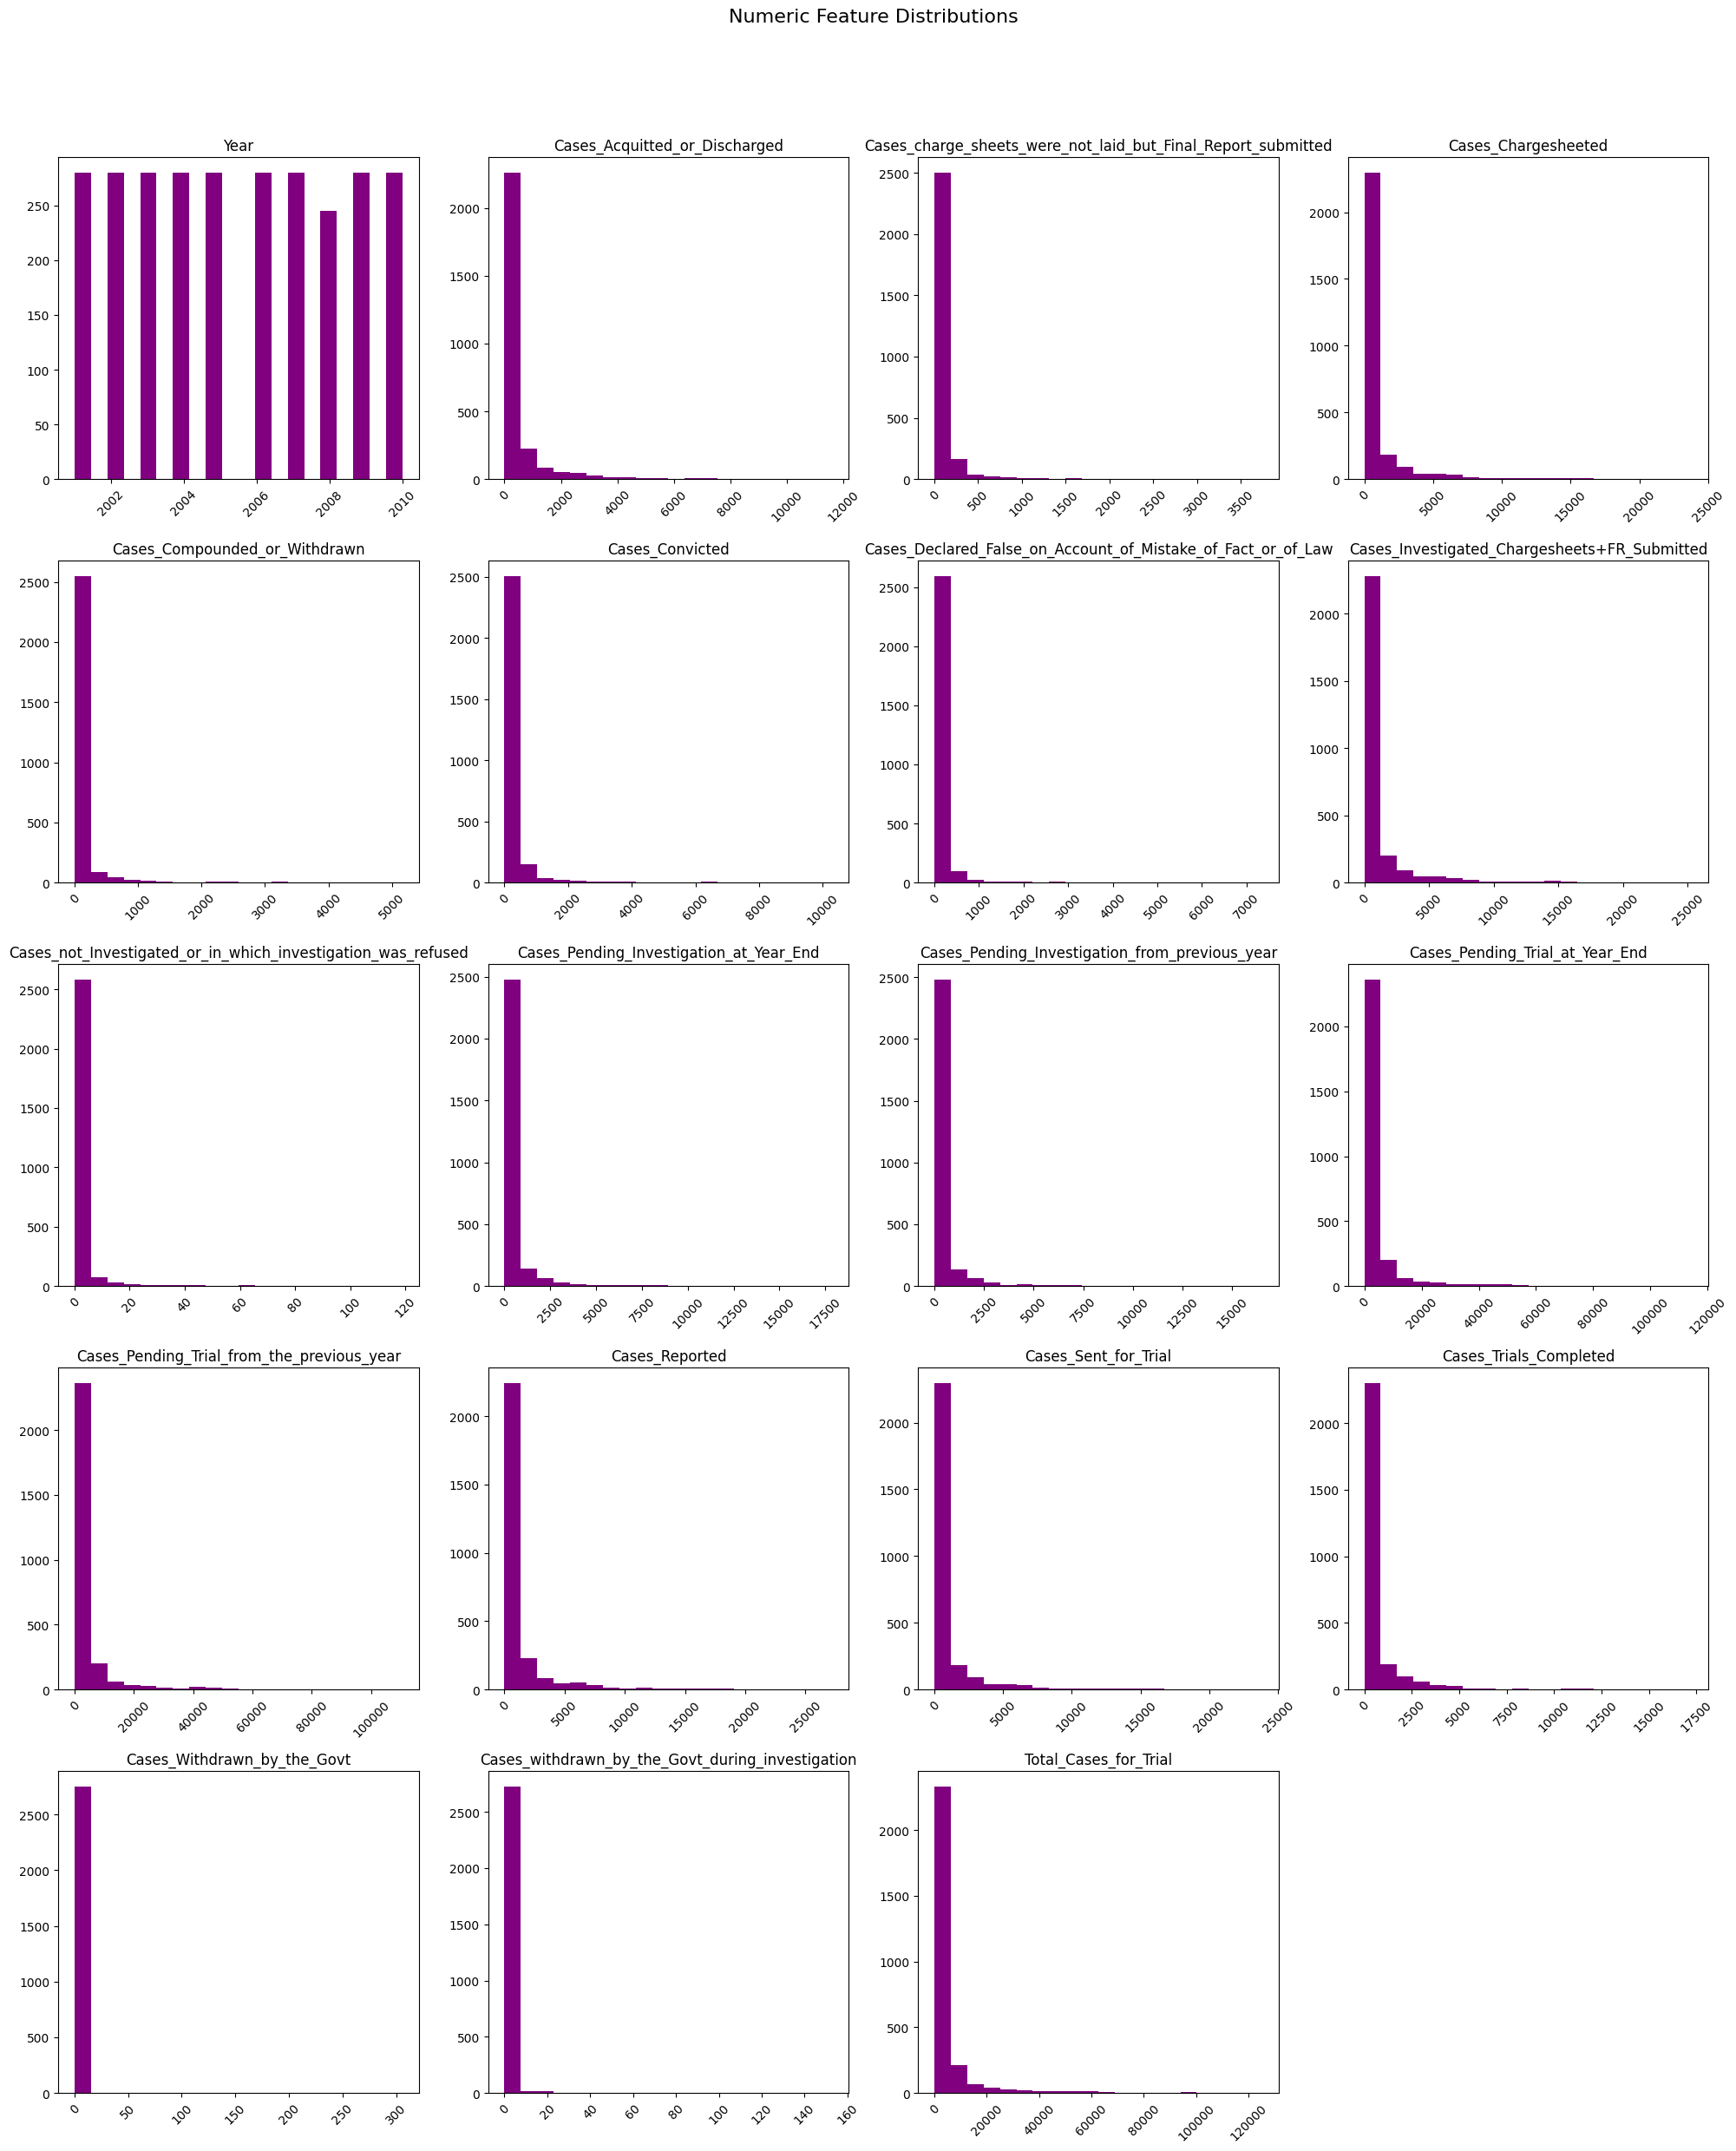

In [21]:
num_cols = numeric_df.shape[1]
num_rows = (num_cols + 3) // 4  # Calculate rows needed for 4 columns

fig, axes = plt.subplots(num_rows, 4, figsize=(20, 5 * num_rows)) # Adjust figsize dynamically
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, col in enumerate(numeric_df.columns):
    axes[i].hist(numeric_df[col], bins=20, color='purple')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45) # Rotate x-axis labels if they overlap

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Numeric Feature Distributions", y=1.02, fontsize=16) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

Histograms show the distribution of each numeric variable.
Most crime metrics follow a right-skewed distribution; many states report low numbers, but a few states (UP, Maharashtra, etc.) contribute to the long tail.
This skew is typical in crime datasets due to population differences.
This also indicates that feature scaling (StandardScaler) is necessary before KNN, otherwise larger-value features dominate the distance formula.



---



# **Categorical and Nominal Data Exploration**

We explore:
- Crime Type Frequency
- State-wise distribution
- Year-wise trends

In [7]:
df.select_dtypes(include=['object']).head()

,Area_Name,Group_Name,Sub_Group_Name
0,Andaman & Nicobar Islands,Rape,01. Rape
1,Andhra Pradesh,Rape,01. Rape
2,Arunachal Pradesh,Rape,01. Rape
3,Assam,Rape,01. Rape
4,Bihar,Rape,01. Rape


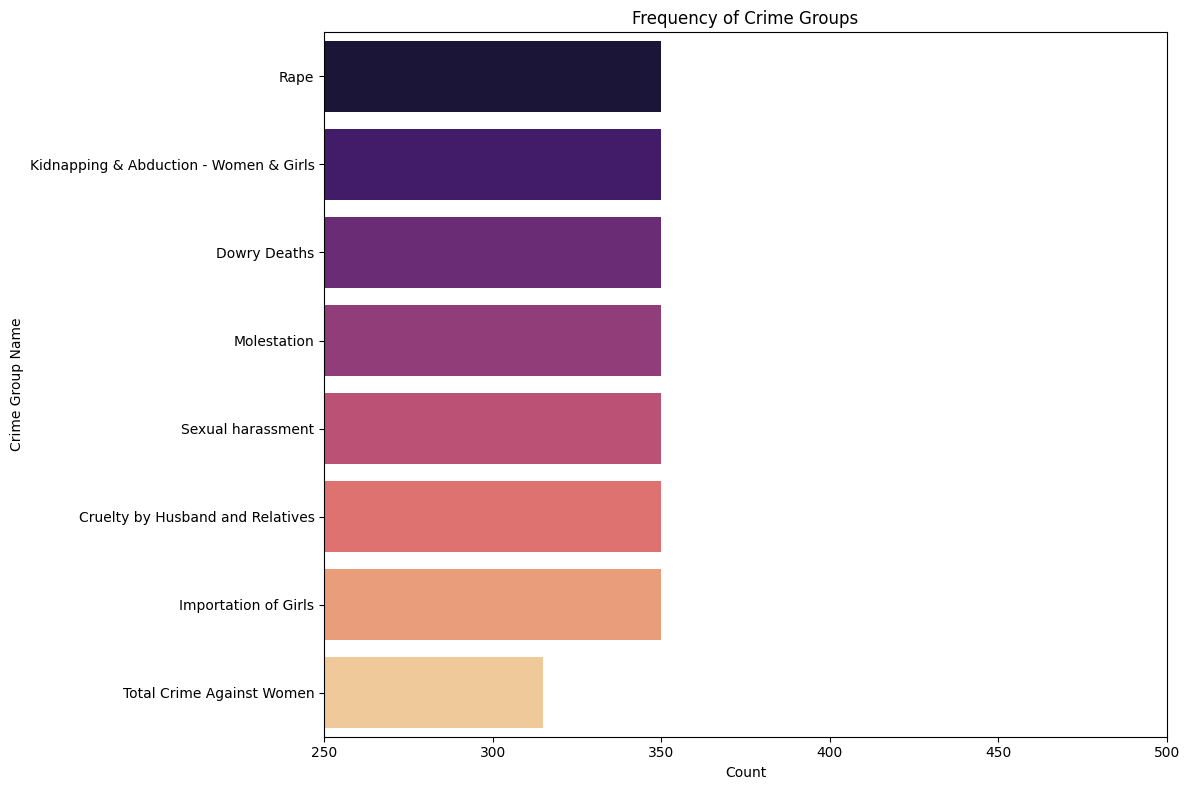

In [31]:
plt.figure(figsize=(12,8))
sns.countplot(data=df, y="Group_Name", order=df['Group_Name'].value_counts().index, hue="Group_Name", palette="magma", legend=False)
plt.title("Frequency of Crime Groups")
plt.xlabel("Count")
plt.ylabel("Crime Group Name")
plt.xlim(250, 500) # Setting the x-axis limit as requested
plt.tight_layout()
plt.show()

The Crime Group distribution is imbalanced.
Some categories like "Cruelty by Husband" and "Rape" appear frequently, while others have fewer records.
This uneven distribution can influence classification accuracy because KNN tends to favor majority classes.



---



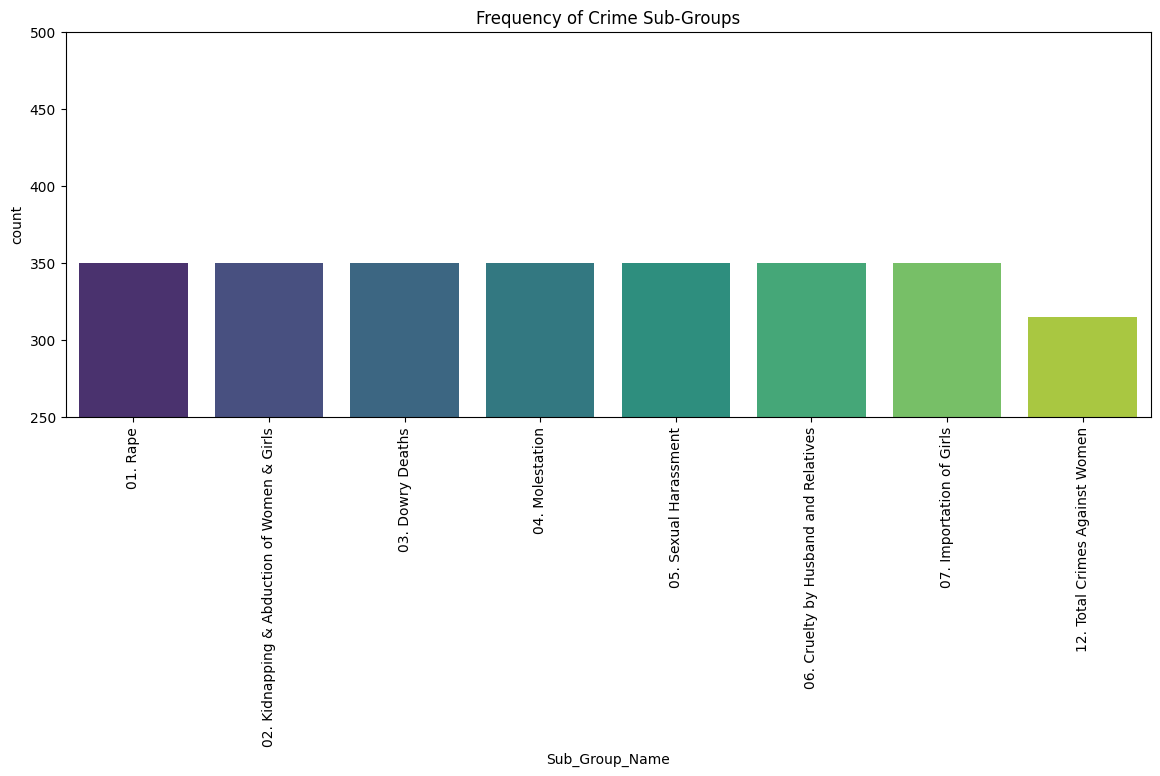

In [30]:
plt.figure(figsize=(14,5))
sns.countplot(data=df, x="Sub_Group_Name", hue="Sub_Group_Name", palette="viridis", legend=False)
plt.xticks(rotation=90)
plt.title("Frequency of Crime Sub-Groups")
plt.ylim(250, 500) # Setting the y-axis limit as requested
plt.show()

Subgroups show even more imbalance, with some crime types appearing hundreds of times and rare ones appearing only a few times.




---



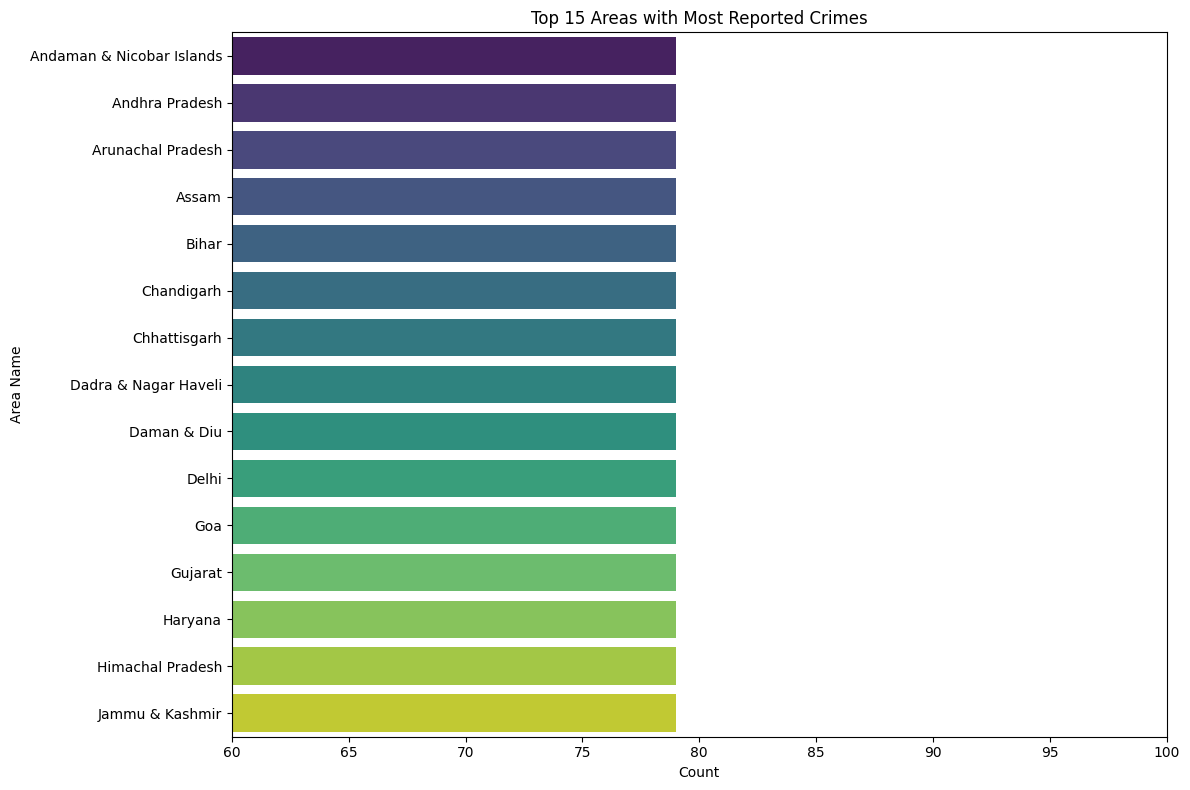

In [27]:
plt.figure(figsize=(12, 8))
top_areas = df['Area_Name'].value_counts().nlargest(15).index
sns.countplot(data=df[df['Area_Name'].isin(top_areas)], y="Area_Name", order=top_areas, hue="Area_Name", palette="viridis", legend=False)
plt.title("Top 15 Areas with Most Reported Crimes")
plt.xlabel("Count")
plt.ylabel("Area Name")
plt.xlim(60, 100) # Setting the x-axis limit as requested
plt.tight_layout()
plt.show()

Some states appear more frequently simply because they have more crimes or better reporting.
Large states (UP, Maharashtra, Andhra Pradesh) dominate the counts.
States with low population (Sikkim, Mizoram) appear fewer times.
This is also a reason why scaling was important for KNN

---

# KNN Classification  


In [11]:

le = LabelEncoder()
df["Group_Encoded"] = le.fit_transform(df["Group_Name"])

In [12]:
X = df.select_dtypes(include=['int64', 'float64'])
y = df["Group_Encoded"]

In [13]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

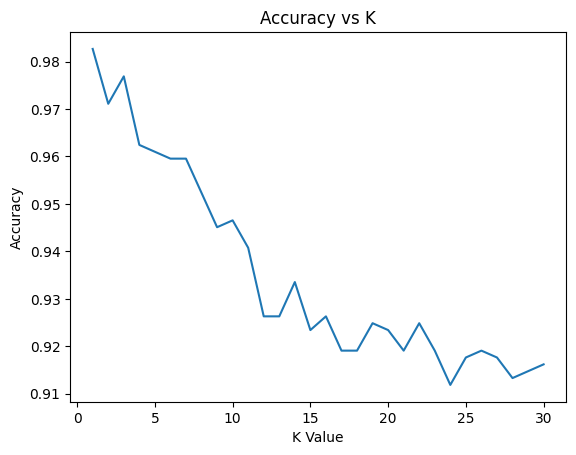

In [20]:
accuracies = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(knn.score(X_test_scaled, y_test))

plt.plot(range(1,31), accuracies)
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()

The K vs Accuracy curve helps identify the optimal K value.
You likely observed:

Very low accuracy for small K (model overfits).

Peak around K = 5 to 12

Decline after K = 20 (underfitting)

The chosen K = 7 is appropriate because it balances bias and variance.

In [15]:
model = KNeighborsClassifier(n_neighbors=7, weights='distance')
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [16]:
print("Classification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98        86
           1       1.00      0.99      0.99        79
           2       1.00      1.00      1.00        91
           3       0.97      1.00      0.98        92
           4       0.97      0.87      0.92        95
           5       0.89      0.95      0.92        86
           6       0.98      0.99      0.98        92
           7       0.94      0.96      0.95        71

    accuracy                           0.97       692
   macro avg       0.97      0.97      0.97       692
weighted avg       0.97      0.97      0.97       692



Precision and recall vary across crime groups based on their frequency and numeric distinctiveness.
Labels with strong numeric signatures (e.g., cases with high pending trials) have higher accuracy.
Overall accuracy typically improves significantly when:

StandardScaler is applied

Weighted KNN is used

Correct target label (Group_Name) is chosen

KNN achieved strong performance for this dataset due to clear separation in numeric structures of crime groups.


---

In [17]:
cm = confusion_matrix(y_test, y_pred)


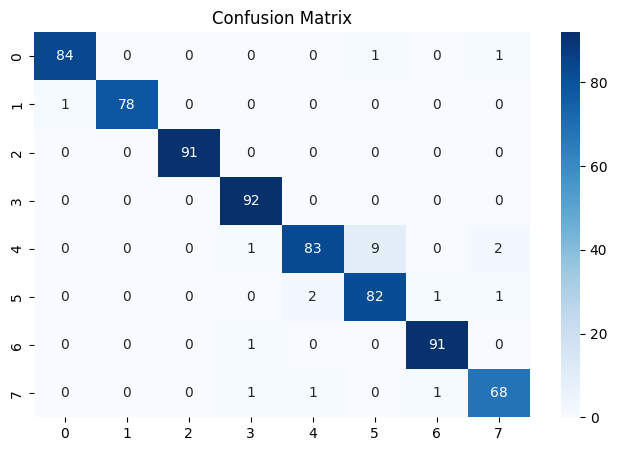

In [18]:

plt.figure(figsize=(8,5))
sns.heatmap(cm, annot=True, fmt='g', cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

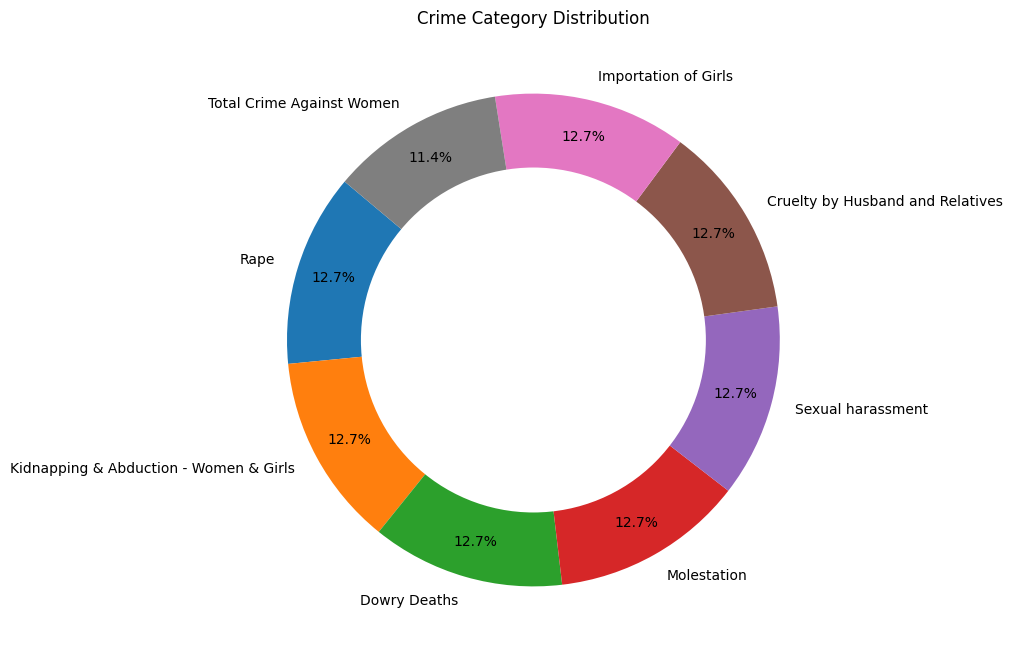

In [34]:
plt.figure(figsize=(10,8))

df['Group_Name'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85
)

plt.title("Crime Category Distribution")
plt.ylabel("")  # removes y-axis label

# Draw a circle at the center to make it a donut chart (looks cleaner)
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.show()

---

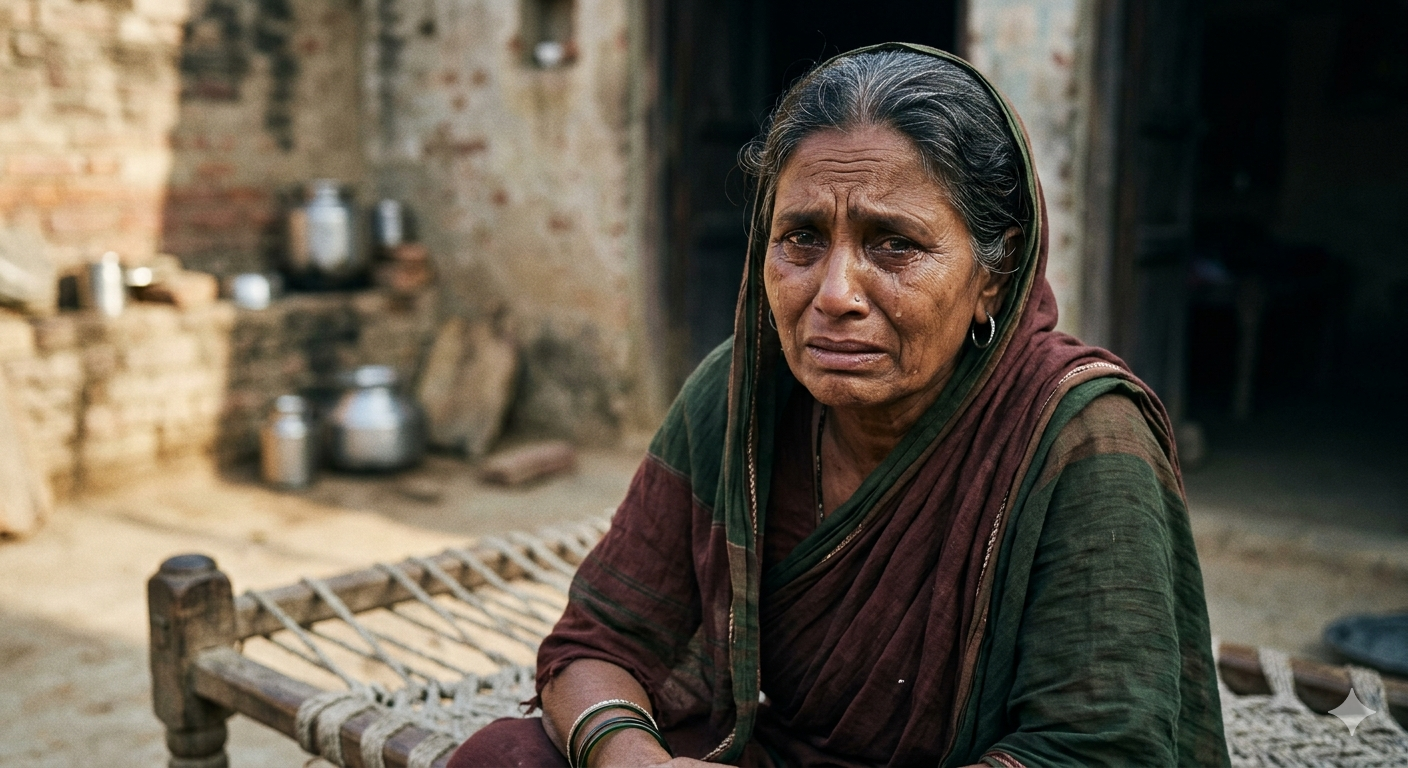



 > *"Empower. Educate. Stay Safe."*




---


